Calculates spacial and temporal nonstationarity index

Left column - Time series with windows:

Shows the full filtered signal
Alternating colored shading for each window
Horizontal lines showing each window's mean
Window numbers (W1, W2, etc.) labeled at the top


Middle column - Window statistics:

Window means with error bars (standard deviations)
Dashed line showing the overall mean across all windows
Helps identify which windows have high/low variability


Right column - Window mean deviations:

Bar chart showing how each window's mean deviates from the overall mean
Critical for understanding NSI (NSI measures the variability of these deviations)
NSI value displayed in the corner

In [58]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy.signal import detrend, butter, filtfilt
import matplotlib.pyplot as plt
def compute_spatial_nsi(markers: xr.DataArray,
                        window_samples: int = 500,
                        fs: float = 100.0) -> dict:
    """
    
     1) Extract 'COM' channel, transpose to dims ('time','axis')
     2) Detrend all axes (x, y, z) with a 0.1 Hz high-pass filter
     3) Anchor each filtered axis so it starts at zero
     4) Compute NSI separately for x, y, z using non-overlapping windows of size `window_samples`

    Parameters
    ----------
    markers : xr.DataArray
        DataArray with dims ('axis','channel','time') and a channel named 'COM'.
    window_samples : int
        Number of time-samples in each non-overlapping window for NSI.
    fs : float
        Sampling rate (Hz) of the COM time series.

    Returns
    -------
    tuple
        - dict: Spatial NSI for each axis: {'x': val, 'y': val, 'z': val}
        - dict: Detailed window results for each axis with (window_range, mean, std) for each window
    """
    # 1) Extract COM channel and reorder dims → (time, axis)
    com = markers.sel(channel='COM').transpose('time', 'axis')
    data = com.values.copy()  # shape: (time, axis)

    # 2) High-pass filter all axes at 0.1 Hz (cutting out drifts > 10 s)
    hp_cutoff = 0.1  # Hz
    b, a = butter(4, hp_cutoff / (fs / 2), btype='highpass')
    
    # Apply filter to each axis
    for i in range(data.shape[1]):
        data[:, i] = filtfilt(b, a, data[:, i])
        # 3) Anchor each axis to start at zero
        data[:, i] -= data[0, i]

    # 4) Rebuild the detrended/filtered COM DataArray
    com_dt = xr.DataArray(data, coords=com.coords, dims=com.dims)

    # Optional: visualize detrended traces for all axes
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axis_names = ['x', 'y', 'z']
    axis_labels = ['ML (x)', 'AP (y)', 'VT (z)']
    
    for idx, (ax_name, ax_label) in enumerate(zip(axis_names, axis_labels)):
        if ax_name in com_dt.axis.values:
            axes[idx].plot(com_dt.sel(axis=ax_name).values, label=f"Filtered {ax_label}")
            axes[idx].set_ylabel(f"{ax_label} Position\n(detrended)")
            axes[idx].legend()
            axes[idx].grid(True)
    
    axes[0].set_title("High-Pass Filtered COM Traces (All Axes)")
    axes[-1].set_xlabel("Sample")
    plt.tight_layout()
    plt.show()

    # 5) NSI helper that returns both overall NSI and per-window details
    def nsi_detailed(ts: np.ndarray, w: int) -> tuple:
        n = len(ts)
        if n < w:
            return np.nan, []
        
        # Get non-overlapping windows
        windows = []
        window_means = []
        window_stds = []
        
        for i in range(0, n - w + 1, w):
            window_data = ts[i:i+w]
            windows.append((i, i+w))
            window_means.append(np.mean(window_data))
            window_stds.append(np.std(window_data, ddof=1))
        
        # Overall statistics
        overall_std = np.std(ts, ddof=1)
        if overall_std == 0:
            return np.nan, []
        
        nsi_value = np.std(window_means, ddof=1) / overall_std
        
        return nsi_value, list(zip(windows, window_means, window_stds))

    # 6) Print window info for the user
    N = com_dt.sizes['time']
    M = (N - window_samples) // window_samples + 1
    print(f"COM series length: {N} samples ({N/fs:.2f} s)")
    print(f"Window size:       {window_samples} samples ({window_samples/fs:.2f} s)")
    print(f"Number of windows: {M}")
    print("-" * 80)

    # 7) Compute NSI per axis with detailed window analysis
    results = {}
    detailed_results = {}
    
    for ax in com_dt.axis.values:
        arr = com_dt.sel(axis=ax).values
        nsi_val, window_details = nsi_detailed(arr, window_samples)
        results[ax] = nsi_val
        detailed_results[ax] = window_details
        
        # Print detailed results for each axis
        print(f"\nAxis: {ax}")
        print(f"Overall NSI: {nsi_val:.4f}")
        print(f"{'Window':<15} {'Time Range (s)':<20} {'Mean':<12} {'Std':<12}")
        print("-" * 60)
        
        for idx, ((start, end), mean, std) in enumerate(window_details):
            time_start = start / fs
            time_end = end / fs
            print(f"Window {idx+1:<8} {time_start:6.2f} - {time_end:6.2f} s    {mean:8.4f}    {std:8.4f}")
    
    # Create comprehensive visualization for window inspection
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    axis_names = ['x', 'y', 'z']
    axis_labels = ['ML (x)', 'AP (y)', 'VT (z)']
    colors = ['blue', 'green', 'red']
    
    for idx, (ax_name, ax_label, color) in enumerate(zip(axis_names, axis_labels, colors)):
        if ax_name in com_dt.axis.values and ax_name in detailed_results:
            # Left column: Full time series with window boundaries
            ax1 = fig.add_subplot(gs[idx, 0])
            time_array = np.arange(len(com_dt.sel(axis=ax_name))) / fs
            ax1.plot(time_array, com_dt.sel(axis=ax_name).values, 'k-', alpha=0.5, linewidth=0.5)
            
            # Overlay each window with different shading
            window_data = detailed_results[ax_name]
            for win_idx, ((start, end), mean, std) in enumerate(window_data):
                t_start = start / fs
                t_end = end / fs
                # Shade window region
                ax1.axvspan(t_start, t_end, alpha=0.2, color=color if win_idx % 2 == 0 else 'gray')
                # Add window mean as horizontal line
                ax1.hlines(mean, t_start, t_end, colors=color, linewidth=2)
                # Add window number
                ax1.text((t_start + t_end) / 2, ax1.get_ylim()[1] * 0.9, f'W{win_idx+1}', 
                        ha='center', va='top', fontsize=8)
            
            ax1.set_ylabel(f'{ax_label} Position')
            ax1.set_title(f'{ax_label} Time Series with Windows')
            ax1.grid(True, alpha=0.3)
            if idx == 2:
                ax1.set_xlabel('Time (s)')
            
            # Middle column: Window means and standard deviations
            ax2 = fig.add_subplot(gs[idx, 1])
            window_indices = list(range(1, len(window_data) + 1))
            window_means = [w[1] for w in window_data]
            window_stds = [w[2] for w in window_data]
            
            # Plot means with error bars (std)
            ax2.errorbar(window_indices, window_means, yerr=window_stds, 
                        fmt='o-', color=color, capsize=5, capthick=2,
                        label='Mean ± Std')
            ax2.axhline(y=np.mean(window_means), color='black', linestyle='--', 
                       alpha=0.5, label='Overall mean')
            
            ax2.set_ylabel('Value')
            ax2.set_title(f'{ax_label} Window Statistics')
            ax2.grid(True, alpha=0.3)
            ax2.legend()
            if idx == 2:
                ax2.set_xlabel('Window Number')
            
            # Right column: Window mean variability (key for NSI)
            ax3 = fig.add_subplot(gs[idx, 2])
            # Show deviation of each window mean from overall mean
            overall_mean = np.mean(com_dt.sel(axis=ax_name).values)
            deviations = [w[1] - overall_mean for w in window_data]
            
            ax3.bar(window_indices, deviations, color=color, alpha=0.7)
            ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
            ax3.set_ylabel('Deviation from Overall Mean')
            ax3.set_title(f'{ax_label} Window Mean Deviations')
            ax3.grid(True, alpha=0.3)
            
            # Add NSI value
            ax3.text(0.98, 0.95, f'NSI = {results.get(ax_name, np.nan):.4f}', 
                    transform=ax3.transAxes, 
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            if idx == 2:
                ax3.set_xlabel('Window Number')
    
    fig.suptitle(f'NSI Window Analysis (Window size: {window_samples/fs:.1f}s, Total: {N/fs:.1f}s)', 
                 fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Additional summary plot: Window means across all axes
    fig2, ax = plt.subplots(figsize=(12, 6))
    
    for ax_name, color in zip(axis_names, colors):
        if ax_name in detailed_results:
            window_data = detailed_results[ax_name]
            if window_data:
                window_centers = [(w[0][0] + w[0][1]) / 2 / fs for w in window_data]
                window_means = [w[1] for w in window_data]
                
                ax.plot(window_centers, window_means, 'o-', color=color, 
                       label=f'{ax_name.upper()} (NSI={results.get(ax_name, np.nan):.4f})',
                       markersize=8, linewidth=2)
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Window Mean Position')
    ax.set_title('Window Means Comparison Across All Axes')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return results, detailed_results
# def compute_spatial_nsi(markers: xr.DataArray,
#                         window_samples: int = 500,
#                         fs: float = 100.0) -> dict:
#     """
    
#      1) Extract 'COM' channel, transpose to dims ('time','axis')
#      2) Detrend all axes (x, y, z) with a 0.1 Hz high-pass filter
#      3) Anchor each filtered axis so it starts at zero
#      4) Compute NSI separately for x, y, z using non-overlapping windows of size `window_samples`

#     Parameters
#     ----------
#     markers : xr.DataArray
#         DataArray with dims ('axis','channel','time') and a channel named 'COM'.
#     window_samples : int
#         Number of time-samples in each non-overlapping window for NSI.
#     fs : float
#         Sampling rate (Hz) of the COM time series.

#     Returns
#     -------
#     dict
#         Spatial NSI for each axis: {'x': val, 'y': val, 'z': val}
#     """
#     # 1) Extract COM channel and reorder dims → (time, axis)
#     com = markers.sel(channel='COM').transpose('time', 'axis')
#     data = com.values.copy()  # shape: (time, axis)

#     # 2) High-pass filter all axes at 0.1 Hz (cutting out drifts > 10 s)
#     hp_cutoff = 0.1  # Hz
#     b, a = butter(4, hp_cutoff / (fs / 2), btype='highpass')
    
#     # Apply filter to each axis
#     for i in range(data.shape[1]):
#         data[:, i] = filtfilt(b, a, data[:, i])
#         # 3) Anchor each axis to start at zero
#         data[:, i] -= data[0, i]

#     # 4) Rebuild the detrended/filtered COM DataArray
#     com_dt = xr.DataArray(data, coords=com.coords, dims=com.dims)

#     # Optional: visualize detrended traces for all axes
#     fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
#     axis_names = ['x', 'y', 'z']
#     axis_labels = ['ML (x)', 'AP (y)', 'VT (z)']
    
#     for idx, (ax_name, ax_label) in enumerate(zip(axis_names, axis_labels)):
#         if ax_name in com_dt.axis.values:
#             axes[idx].plot(com_dt.sel(axis=ax_name).values, label=f"Filtered {ax_label}")
#             axes[idx].set_ylabel(f"{ax_label} Position\n(detrended)")
#             axes[idx].legend()
#             axes[idx].grid(True)
    
#     axes[0].set_title("High-Pass Filtered COM Traces (All Axes)")
#     axes[-1].set_xlabel("Sample")
#     plt.tight_layout()
#     plt.show()

#     # 5) NSI helper on a 1D array
#     def nsi(ts: np.ndarray, w: int) -> float:
#         n = len(ts)
#         if n < w or np.std(ts, ddof=1) == 0:
#             return np.nan
#         block_means = [ts[i:i+w].mean() for i in range(0, n - w + 1, w)]
#         return np.std(block_means, ddof=1) / np.std(ts, ddof=1)

#     # 6) Print window info for the user
#     N = com_dt.sizes['time']
#     M = (N - window_samples) // window_samples + 1
#     print(f"COM series length: {N} samples ({N/fs:.2f} s)")
#     print(f"Window size:       {window_samples} samples ({window_samples/fs:.2f} s)")
#     print(f"Number of windows: {M}")

#     # 7) Compute NSI per axis
#     results = {}
#     for ax in com_dt.axis.values:
#         arr = com_dt.sel(axis=ax).values
#         results[ax] = nsi(arr, window_samples)

#     return results
def compute_temporal_nsi_from_events(events_df: pd.DataFrame,
                                     strides_per_window: int = 10,
                                     trim_strides: int = 5,
                                     outlier_thresh: float = 3.0) -> float:
    """
    Compute temporal NSI over the full trial from a CSV of events.

    Expects columns:
      - time: float (event timestamp, in seconds)
      - leg:  str   ('Left' or 'Right')
      - event: str  (e.g. 'Foot Strike')

    Steps:
      1) Keep only rows where event == 'Foot Strike'
      2) Extract timestamps for Left vs. Right
      3) Compute per-side stride intervals (diff of successive times)
      4) Pool Left+Right intervals into one array
      5) Trim the first/last `trim_strides` intervals (belt ramp artifacts)
      6) Discard intervals beyond ± outlier_thresh × SD
      7) NSI = SD(non-overlapping block-means) / SD(full interval series)

    Parameters
    ----------
    events_df : pd.DataFrame
        Must contain columns ['time','leg','event'].
        'leg' should be 'Left' or 'Right'. 'event' should include 'Foot Strike'.
    strides_per_window : int
        Number of strides in each non-overlapping window for NSI.
    trim_strides : int
        Number of strides to drop at start and end to avoid transients.
    outlier_thresh : float
        Discard any interval that is farther than ± outlier_thresh × SD from the mean.

    Returns
    -------
    float
        Temporal NSI for the pooled stride-time series.
    """
    # 1) Keep only Foot Strike rows
    df_fs = events_df[events_df['label'] == 'Foot Strike'].copy()

    # 2) Sorted timestamp arrays by leg
    tL = np.sort(df_fs.loc[df_fs['context'] == 'Left',  'time'].values)
    tR = np.sort(df_fs.loc[df_fs['context'] == 'Right', 'time'].values)

    # 3) Compute stride intervals per side
    strides_L = np.diff(tL)
    strides_R = np.diff(tR)

    # 4) Pool into one array
    all_strides = np.concatenate([strides_L, strides_R])

    # 5) Trim first/last trim_strides to drop belt ramp-up/down
    if len(all_strides) > 2 * trim_strides:
        all_strides = all_strides[trim_strides:-trim_strides]

    # 6) Remove outliers beyond ± outlier_thresh × SD
    mu, sigma = all_strides.mean(), all_strides.std(ddof=1)
    mask = np.abs(all_strides - mu) <= outlier_thresh * sigma
    all_strides = all_strides[mask]

    # 7) NSI helper: std of non-overlapping window-means / std of full series
    def nsi(ts: np.ndarray, k: int) -> float:
        n = len(ts)
        if n < k or np.std(ts, ddof=1) == 0:
            return np.nan
        block_means = [ts[i:i + k].mean() for i in range(0, n - k + 1, k)]
        return np.std(block_means, ddof=1) / np.std(ts, ddof=1)

    return nsi(all_strides, strides_per_window)






# Patient 13

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Markers DataArray loaded with shape: (3, 95, 27728)
Events DataFrame loaded with shape: (712, 4)
Temporal NSI: 0.5332557729415615


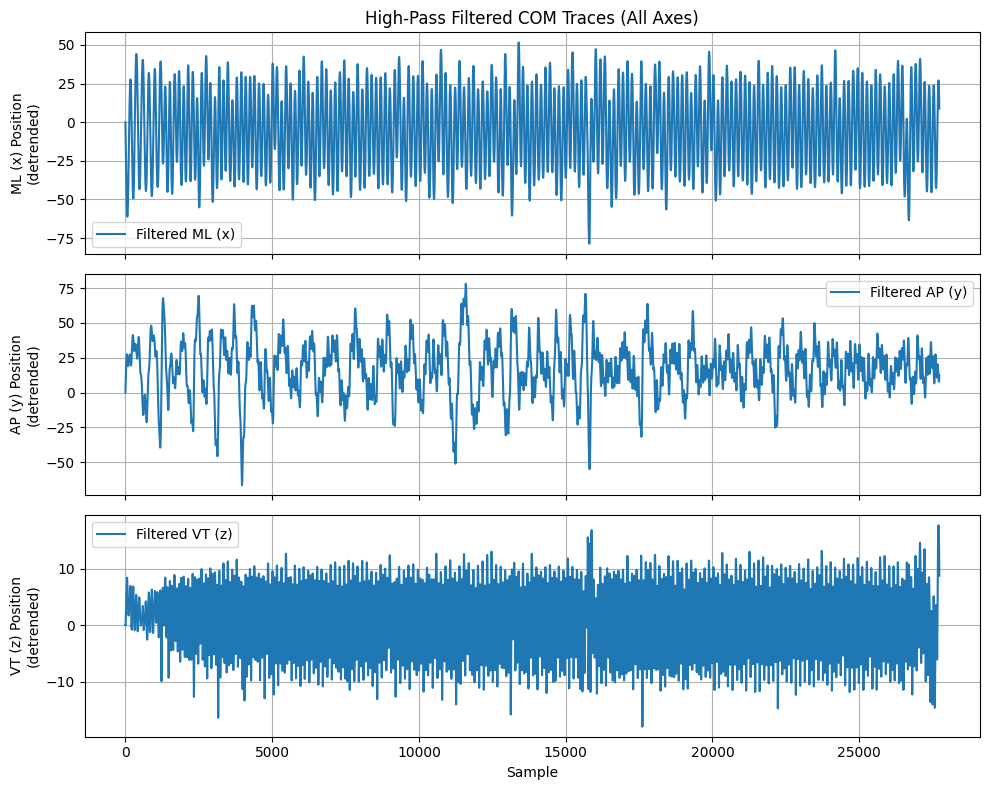

COM series length: 27728 samples (277.28 s)
Window size:       500 samples (5.00 s)
Number of windows: 55
--------------------------------------------------------------------------------

Axis: x
Overall NSI: 0.1302
Window          Time Range (s)       Mean         Std         
------------------------------------------------------------
Window 1          0.00 -   5.00 s    -12.4089     32.0576
Window 2          5.00 -  10.00 s     -3.8785     28.8950
Window 3         10.00 -  15.00 s     -5.0033     26.3039
Window 4         15.00 -  20.00 s     -3.0867     25.6437
Window 5         20.00 -  25.00 s     -5.7831     24.8037
Window 6         25.00 -  30.00 s     -5.1735     29.3975
Window 7         30.00 -  35.00 s     -2.4412     24.8337
Window 8         35.00 -  40.00 s     -5.2362     24.2089
Window 9         40.00 -  45.00 s     -7.2887     25.2441
Window 10        45.00 -  50.00 s     -7.1006     22.4334
Window 11        50.00 -  55.00 s     -0.2140     26.8554
Window 12        55.00

C:\Users\Natascha\AppData\Local\Temp\ipykernel_74216\1935605621.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


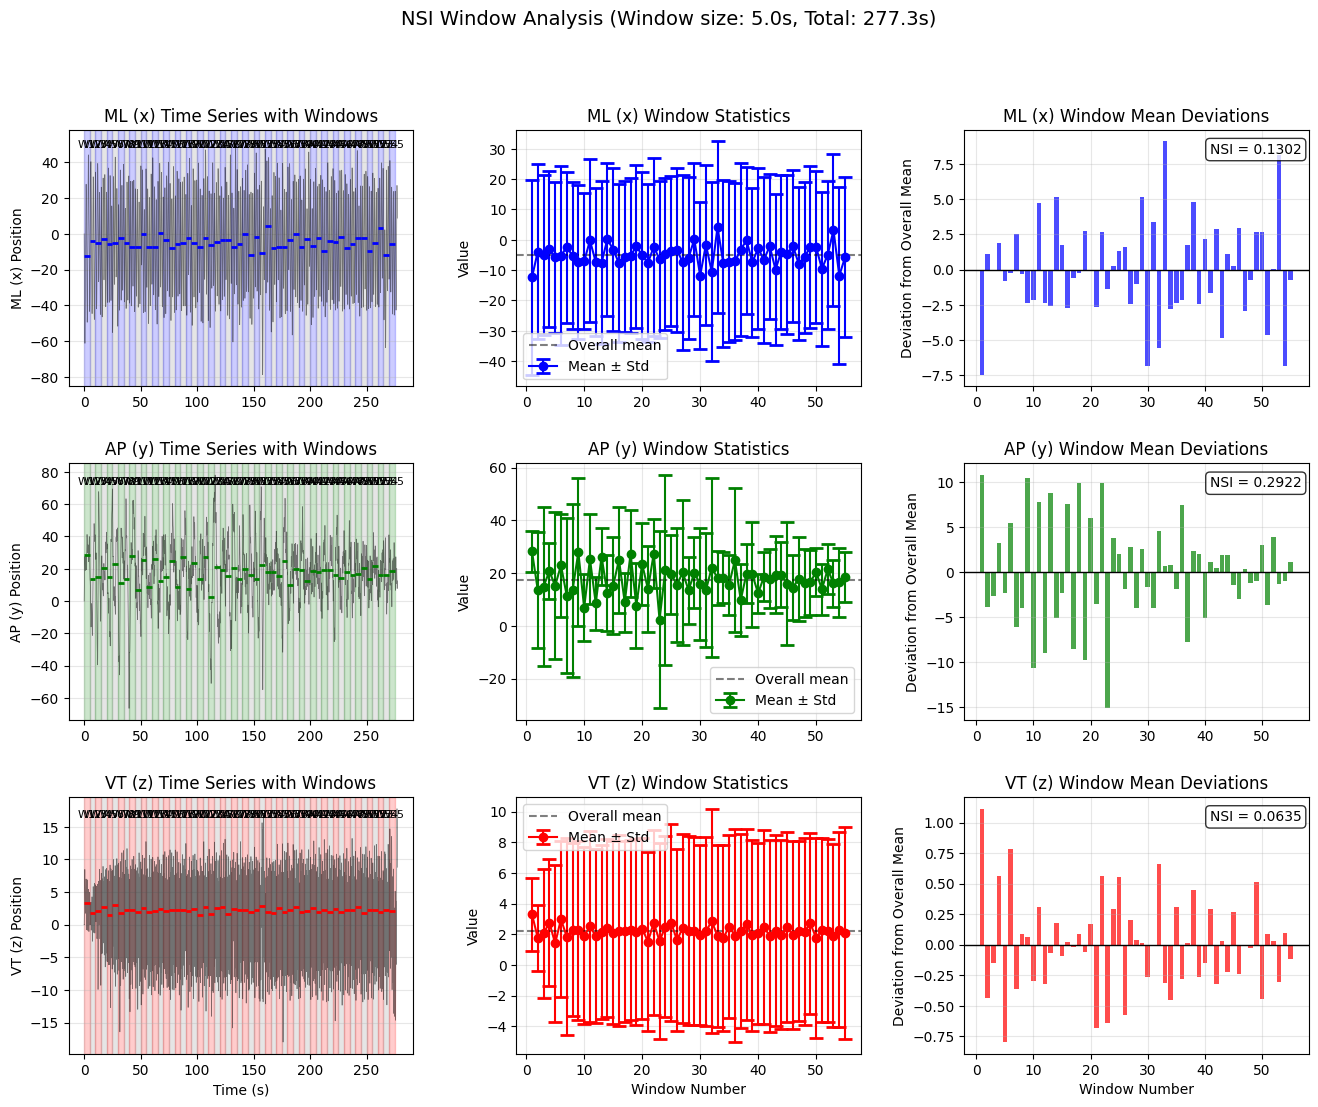

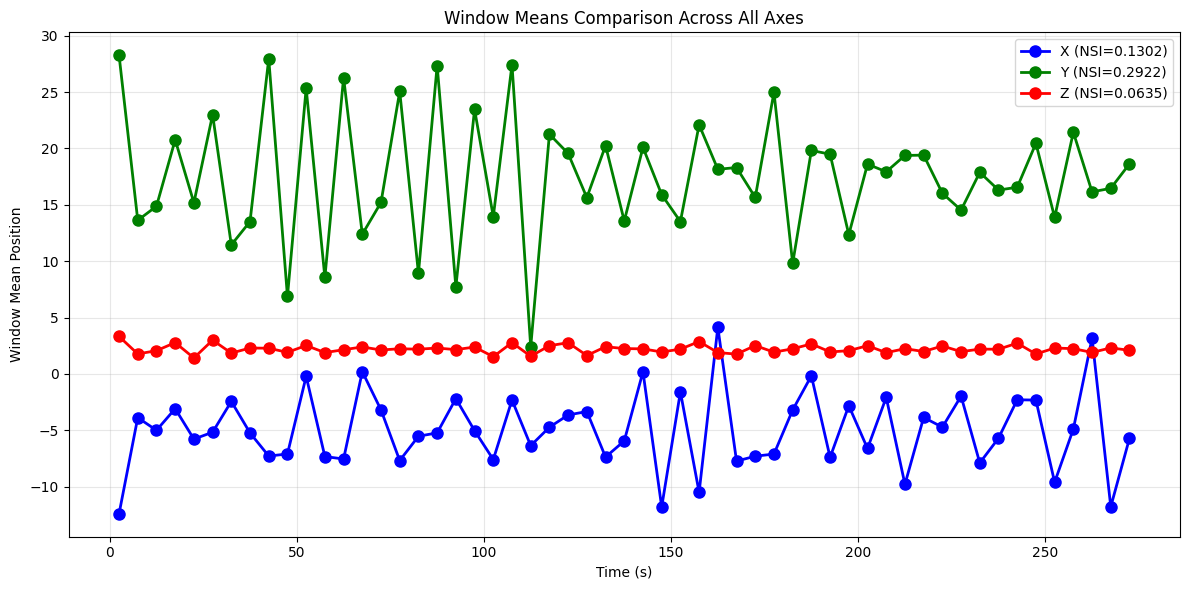

Spatial NSI: ({np.str_('x'): np.float64(0.13021040659753466), np.str_('y'): np.float64(0.29215076265131684), np.str_('z'): np.float64(0.06354200307045275)}, {np.str_('x'): [((0, 500), np.float64(-12.408910758490043), np.float64(32.057571595277736)), ((500, 1000), np.float64(-3.87846034992454), np.float64(28.895039398487505)), ((1000, 1500), np.float64(-5.003316959474449), np.float64(26.30391496015507)), ((1500, 2000), np.float64(-3.086664090650025), np.float64(25.643736410627824)), ((2000, 2500), np.float64(-5.783135610011676), np.float64(24.803679012399186)), ((2500, 3000), np.float64(-5.173543173445525), np.float64(29.397544079934047)), ((3000, 3500), np.float64(-2.441193729611984), np.float64(24.833691314141646)), ((3500, 4000), np.float64(-5.23623418769938), np.float64(24.208936906927306)), ((4000, 4500), np.float64(-7.288681109967033), np.float64(25.24410077534933)), ((4500, 5000), np.float64(-7.1006123251741915), np.float64(22.433422808673892)), ((5000, 5500), np.float64(-0.21399

In [59]:
import pandas as pd
from pathlib import Path
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())

data_path = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
events_path  = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"Cereneo_SR_13_Fam_pre.4_events.csv"

ds = xr.open_dataarray(data_path)
print("Markers DataArray loaded with shape:", ds.shape)
df_events = pd.read_csv(events_path)
print("Events DataFrame loaded with shape:", df_events.shape)

nsi_temporal = compute_temporal_nsi_from_events(df_events, strides_per_window=10, trim_strides=5, outlier_thresh=3.0)
print("Temporal NSI:", nsi_temporal)

nsi_spatial = compute_spatial_nsi(ds, window_samples=500, fs=100.0)
print("Spatial NSI:", nsi_spatial)




# Patient 14

Markers DataArray loaded with shape: (3, 95, 25573)
Events DataFrame loaded with shape: (712, 4)
Temporal NSI: 0.4667101033701592


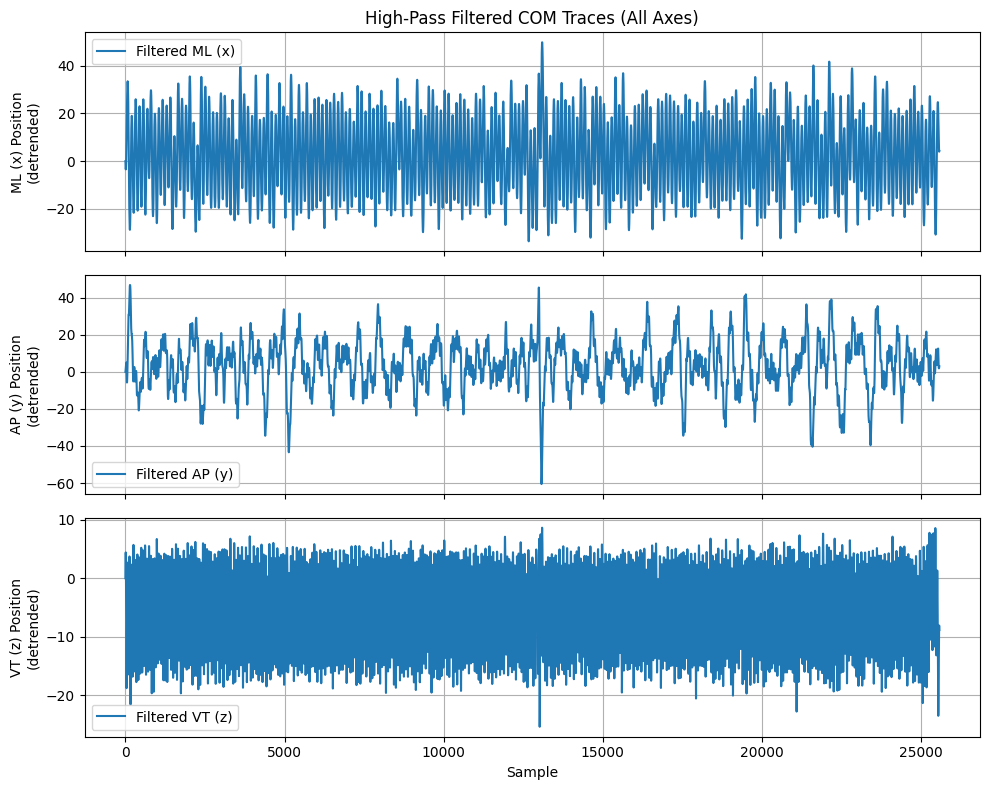

COM series length: 25573 samples (255.73 s)
Window size:       500 samples (5.00 s)
Number of windows: 51
--------------------------------------------------------------------------------

Axis: x
Overall NSI: 0.0978
Window          Time Range (s)       Mean         Std         
------------------------------------------------------------
Window 1          0.00 -   5.00 s      2.6206     17.4828
Window 2          5.00 -  10.00 s      2.3916     16.8547
Window 3         10.00 -  15.00 s      2.8452     16.0780
Window 4         15.00 -  20.00 s      3.3219     15.5571
Window 5         20.00 -  25.00 s      1.6634     18.9065
Window 6         25.00 -  30.00 s      3.8717     16.0469
Window 7         30.00 -  35.00 s      1.5251     16.0089
Window 8         35.00 -  40.00 s      4.1342     18.1121
Window 9         40.00 -  45.00 s      4.6277     17.7169
Window 10        45.00 -  50.00 s      2.1782     16.8354
Window 11        50.00 -  55.00 s      2.0426     18.6936
Window 12        55.00

C:\Users\Natascha\AppData\Local\Temp\ipykernel_74216\1935605621.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


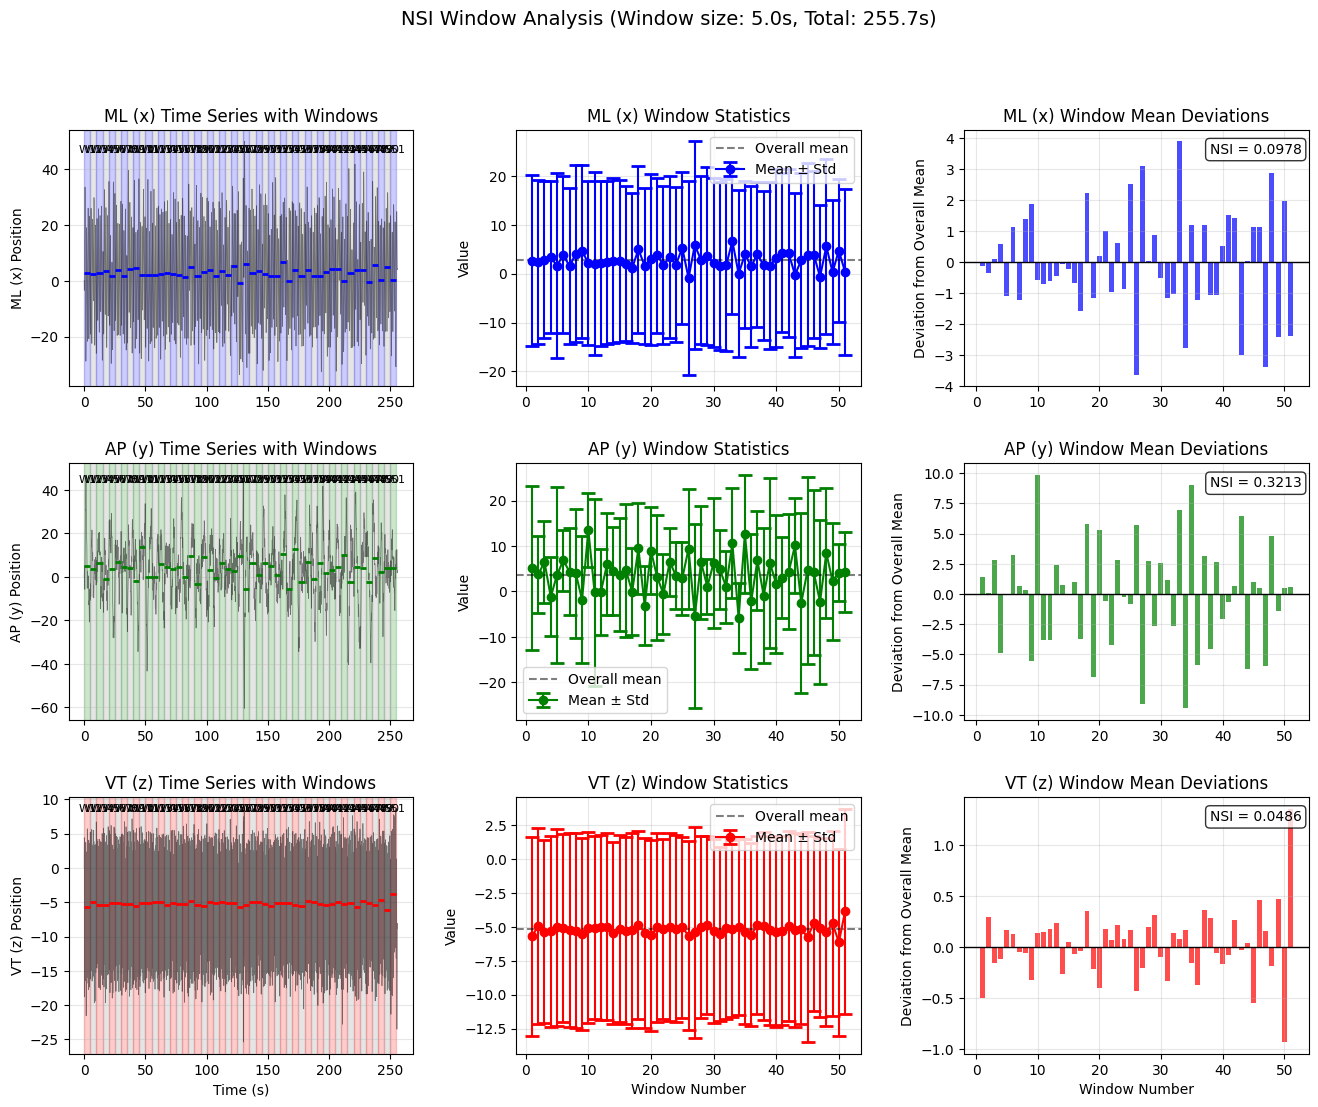

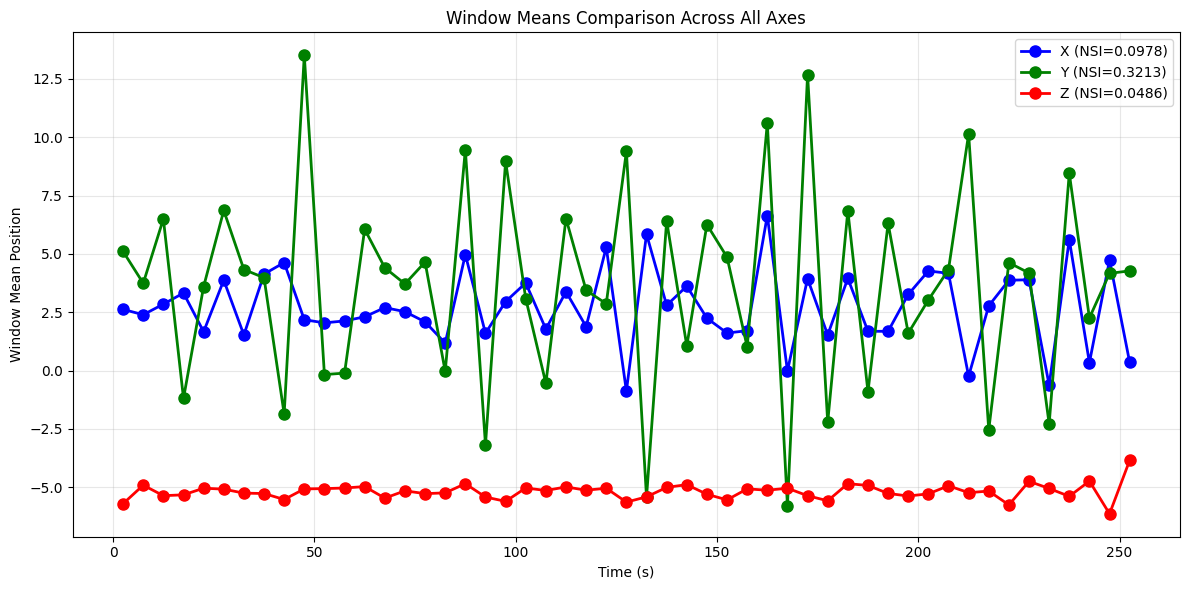

Spatial NSI: ({np.str_('x'): np.float64(0.09778776575609142), np.str_('y'): np.float64(0.32127927980337945), np.str_('z'): np.float64(0.048631344874191705)}, {np.str_('x'): [((0, 500), np.float64(2.6206418073690223), np.float64(17.482777417988203)), ((500, 1000), np.float64(2.391550594030339), np.float64(16.854655068149988)), ((1000, 1500), np.float64(2.845201978486182), np.float64(16.078026362618328)), ((1500, 2000), np.float64(3.3219251972839), np.float64(15.557143459644768)), ((2000, 2500), np.float64(1.663380710056872), np.float64(18.906454031530078)), ((2500, 3000), np.float64(3.871737962743828), np.float64(16.04685393585763)), ((3000, 3500), np.float64(1.5250575499227506), np.float64(16.00887837112388)), ((3500, 4000), np.float64(4.13416261351316), np.float64(18.112074221928395)), ((4000, 4500), np.float64(4.62765341291311), np.float64(17.7168682488601)), ((4500, 5000), np.float64(2.1781966805063098), np.float64(16.835387946003042)), ((5000, 5500), np.float64(2.042564711357439), 

In [51]:
# cwd = Path.cwd()
# print("Current working directory:", cwd.resolve())

data_path = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_14"/"Pre.3" /"markers.nc"
events_path  = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_14"/"Pre.4" /"Cereneo_SR_14_Fam_pre.4_events.csv"

ds_14 = xr.open_dataarray(data_path)
print("Markers DataArray loaded with shape:", ds_14.shape)
df_events_14 = pd.read_csv(events_path)
print("Events DataFrame loaded with shape:", df_events.shape)

nsi_temporal_14 = compute_temporal_nsi_from_events(df_events_14, strides_per_window=10, trim_strides=5, outlier_thresh=3.0)
print("Temporal NSI:", nsi_temporal_14)

nsi_spatial_14 = compute_spatial_nsi(ds_14, window_samples=500, fs=100.0)
print("Spatial NSI:", nsi_spatial_14)

# Patient 15

Markers DataArray loaded with shape: (3, 95, 25570)
Events DataFrame loaded with shape: (934, 4)
Temporal NSI: 0.3541850950336143


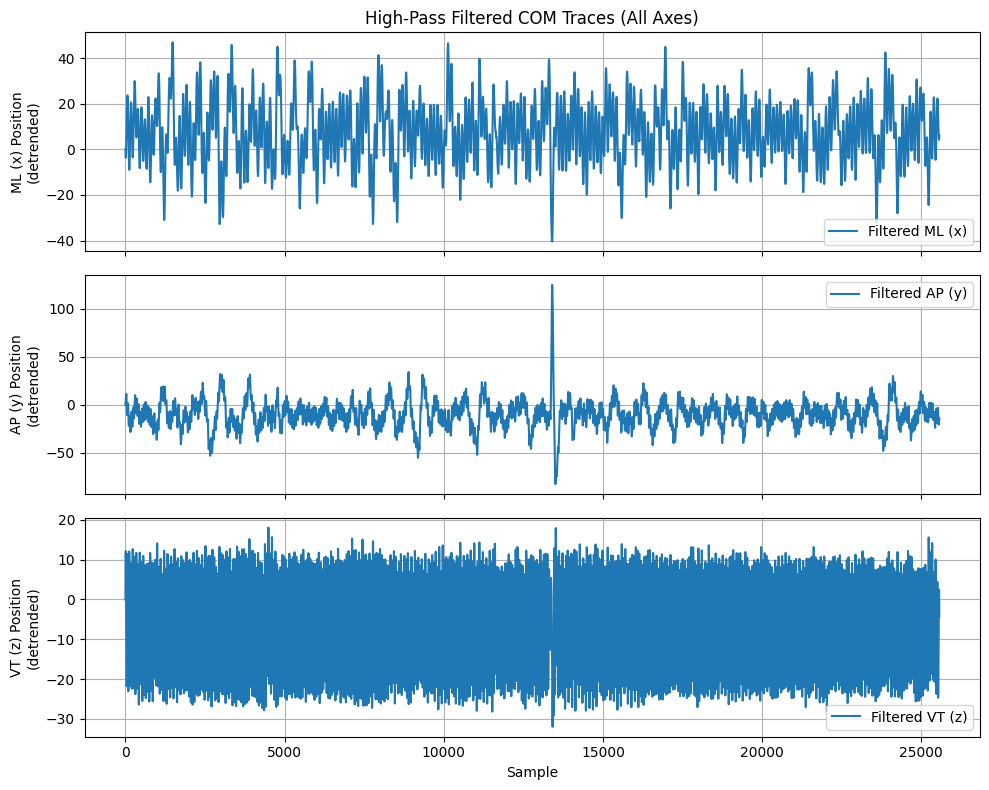

COM series length: 25570 samples (255.70 s)
Window size:       500 samples (5.00 s)
Number of windows: 51
--------------------------------------------------------------------------------

Axis: x
Overall NSI: 0.1877
Window          Time Range (s)       Mean         Std         
------------------------------------------------------------
Window 1          0.00 -   5.00 s      9.2751     10.4993
Window 2          5.00 -  10.00 s      6.5059     10.0304
Window 3         10.00 -  15.00 s     10.8686     19.7388
Window 4         15.00 -  20.00 s      4.0976     13.3013
Window 5         20.00 -  25.00 s      8.1975     15.3526
Window 6         25.00 -  30.00 s      7.7927     18.7395
Window 7         30.00 -  35.00 s     10.4251     19.6136
Window 8         35.00 -  40.00 s      2.9260     13.1565
Window 9         40.00 -  45.00 s      7.9085     12.5160
Window 10        45.00 -  50.00 s      9.6034     17.9000
Window 11        50.00 -  55.00 s      5.3862     16.0250
Window 12        55.00

C:\Users\Natascha\AppData\Local\Temp\ipykernel_74216\1935605621.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


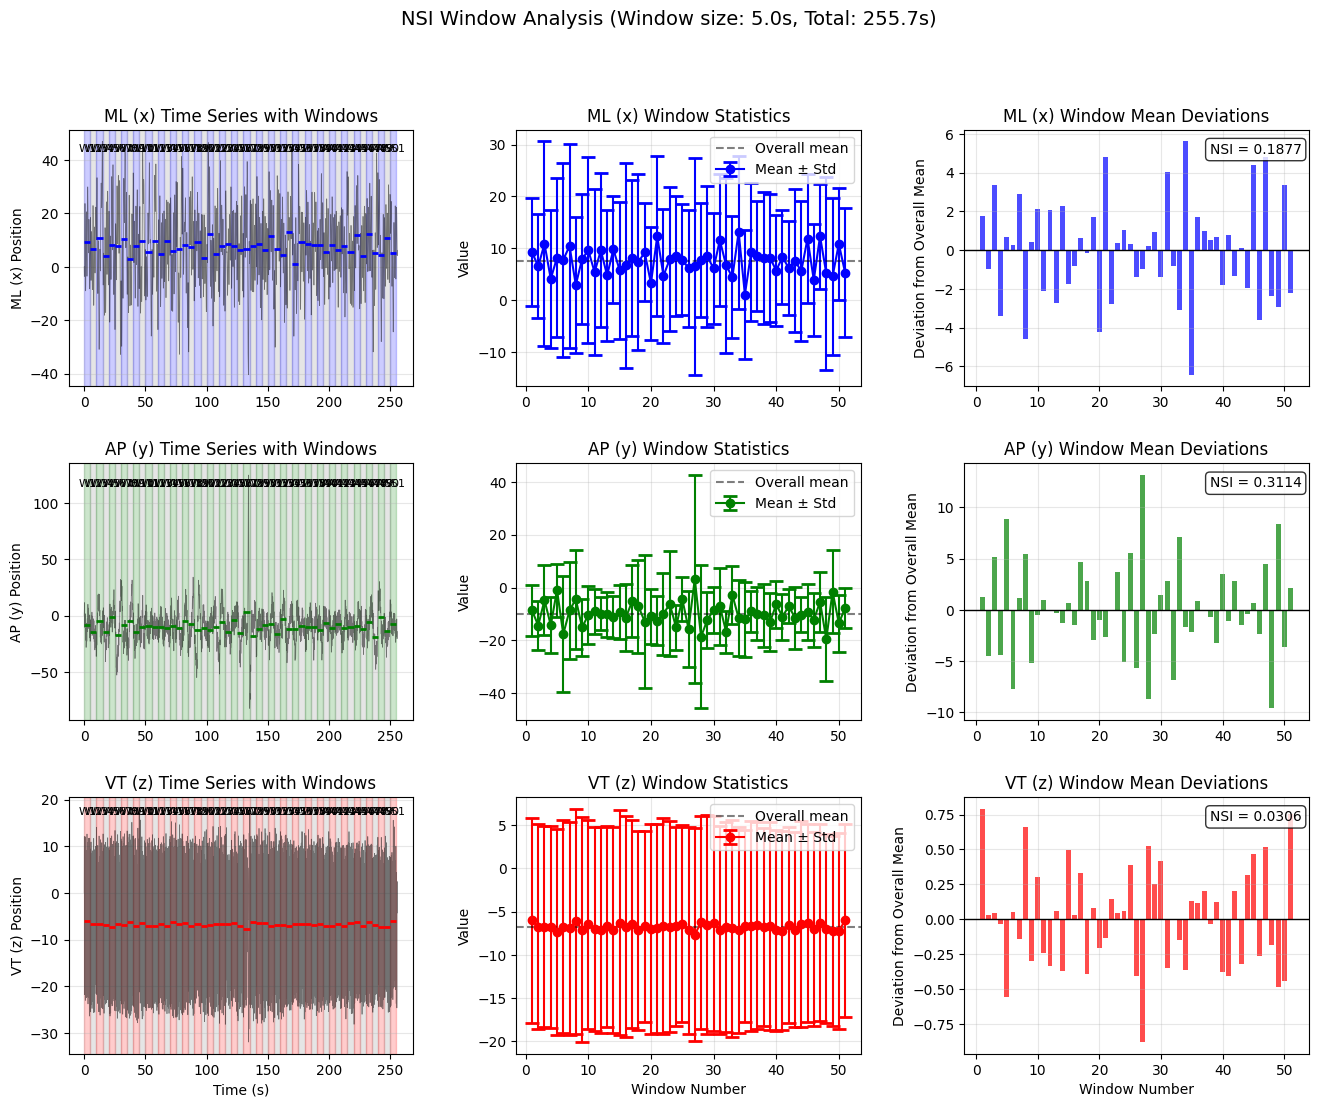

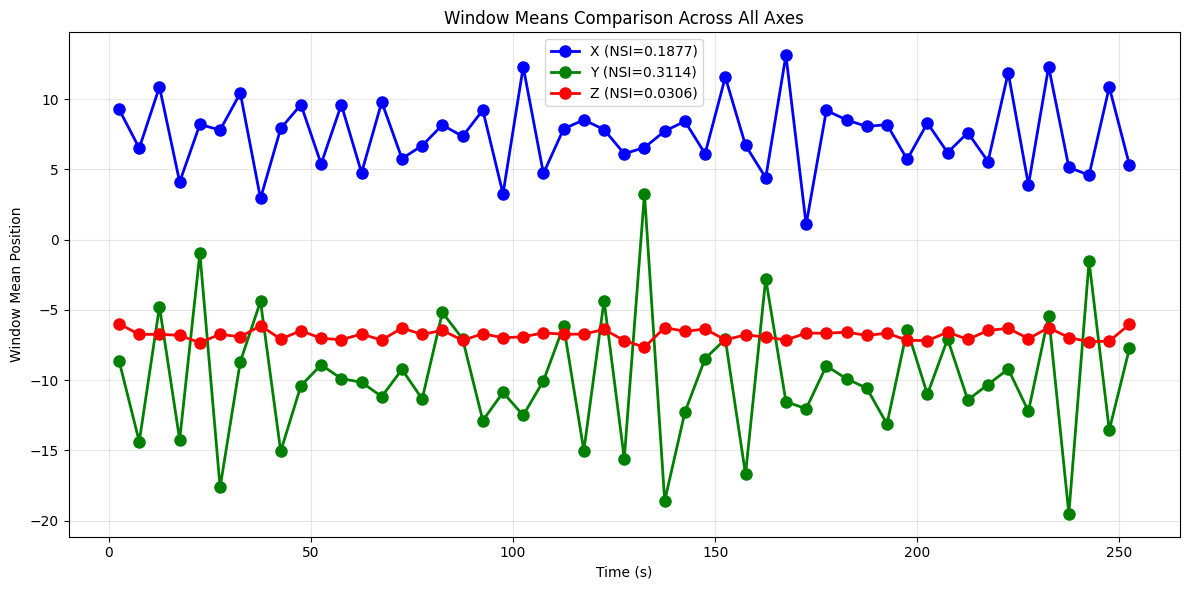

Spatial NSI: ({np.str_('x'): np.float64(0.13021040659753466), np.str_('y'): np.float64(0.29215076265131684), np.str_('z'): np.float64(0.06354200307045275)}, {np.str_('x'): [((0, 500), np.float64(-12.408910758490043), np.float64(32.057571595277736)), ((500, 1000), np.float64(-3.87846034992454), np.float64(28.895039398487505)), ((1000, 1500), np.float64(-5.003316959474449), np.float64(26.30391496015507)), ((1500, 2000), np.float64(-3.086664090650025), np.float64(25.643736410627824)), ((2000, 2500), np.float64(-5.783135610011676), np.float64(24.803679012399186)), ((2500, 3000), np.float64(-5.173543173445525), np.float64(29.397544079934047)), ((3000, 3500), np.float64(-2.441193729611984), np.float64(24.833691314141646)), ((3500, 4000), np.float64(-5.23623418769938), np.float64(24.208936906927306)), ((4000, 4500), np.float64(-7.288681109967033), np.float64(25.24410077534933)), ((4500, 5000), np.float64(-7.1006123251741915), np.float64(22.433422808673892)), ((5000, 5500), np.float64(-0.21399

In [50]:
# cwd = Path.cwd()
# print("Current working directory:", cwd.resolve())

data_path = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_15"/"Pre.3" /"markers.nc"
events_path  = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_15"/"Pre.4" /"Cereneo_SR_15_Fam_pre.4_events.csv"

ds_15 = xr.open_dataarray(data_path)
print("Markers DataArray loaded with shape:", ds_15.shape)
df_events_15 = pd.read_csv(events_path)
print("Events DataFrame loaded with shape:", df_events_15.shape)

nsi_temporal_15 = compute_temporal_nsi_from_events(df_events_15, strides_per_window=10, trim_strides=5, outlier_thresh=3.0)
print("Temporal NSI:", nsi_temporal_15)

nsi_spatial_15 = compute_spatial_nsi(ds_15, window_samples=500, fs=100.0)
print("Spatial NSI:", nsi_spatial)


# 

# Patient 16

Markers DataArray loaded with shape: (3, 95, 25372)
Events DataFrame loaded with shape: (905, 4)
Temporal NSI: 0.5030929313882855


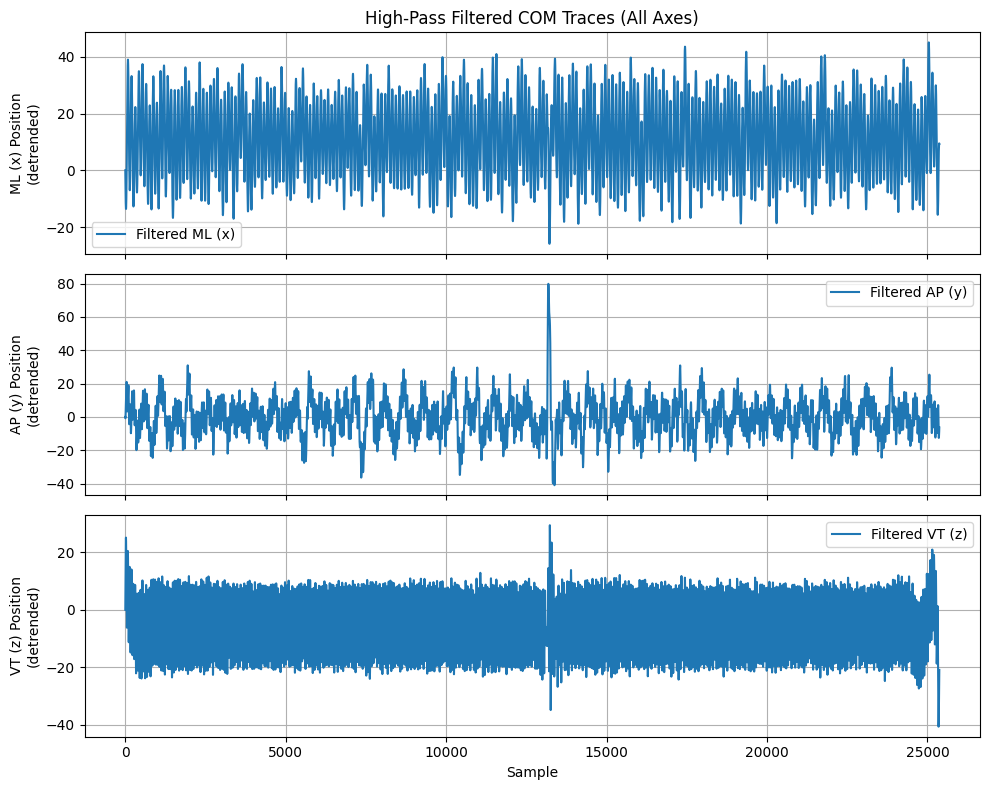

COM series length: 25372 samples (253.72 s)
Window size:       500 samples (5.00 s)
Number of windows: 50
--------------------------------------------------------------------------------

Axis: x
Overall NSI: 0.1157
Window          Time Range (s)       Mean         Std         
------------------------------------------------------------
Window 1          0.00 -   5.00 s     10.4244     15.4975
Window 2          5.00 -  10.00 s     11.2997     14.6887
Window 3         10.00 -  15.00 s     11.2290     15.7182
Window 4         15.00 -  20.00 s     12.5584     13.8240
Window 5         20.00 -  25.00 s      9.0985     14.0327
Window 6         25.00 -  30.00 s     13.0817     13.2005
Window 7         30.00 -  35.00 s      8.0099     14.4327
Window 8         35.00 -  40.00 s     12.0106     14.4490
Window 9         40.00 -  45.00 s     11.7075     12.6860
Window 10        45.00 -  50.00 s     12.7282     12.5724
Window 11        50.00 -  55.00 s      9.1282     12.0234
Window 12        55.00

C:\Users\Natascha\AppData\Local\Temp\ipykernel_74216\1935605621.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


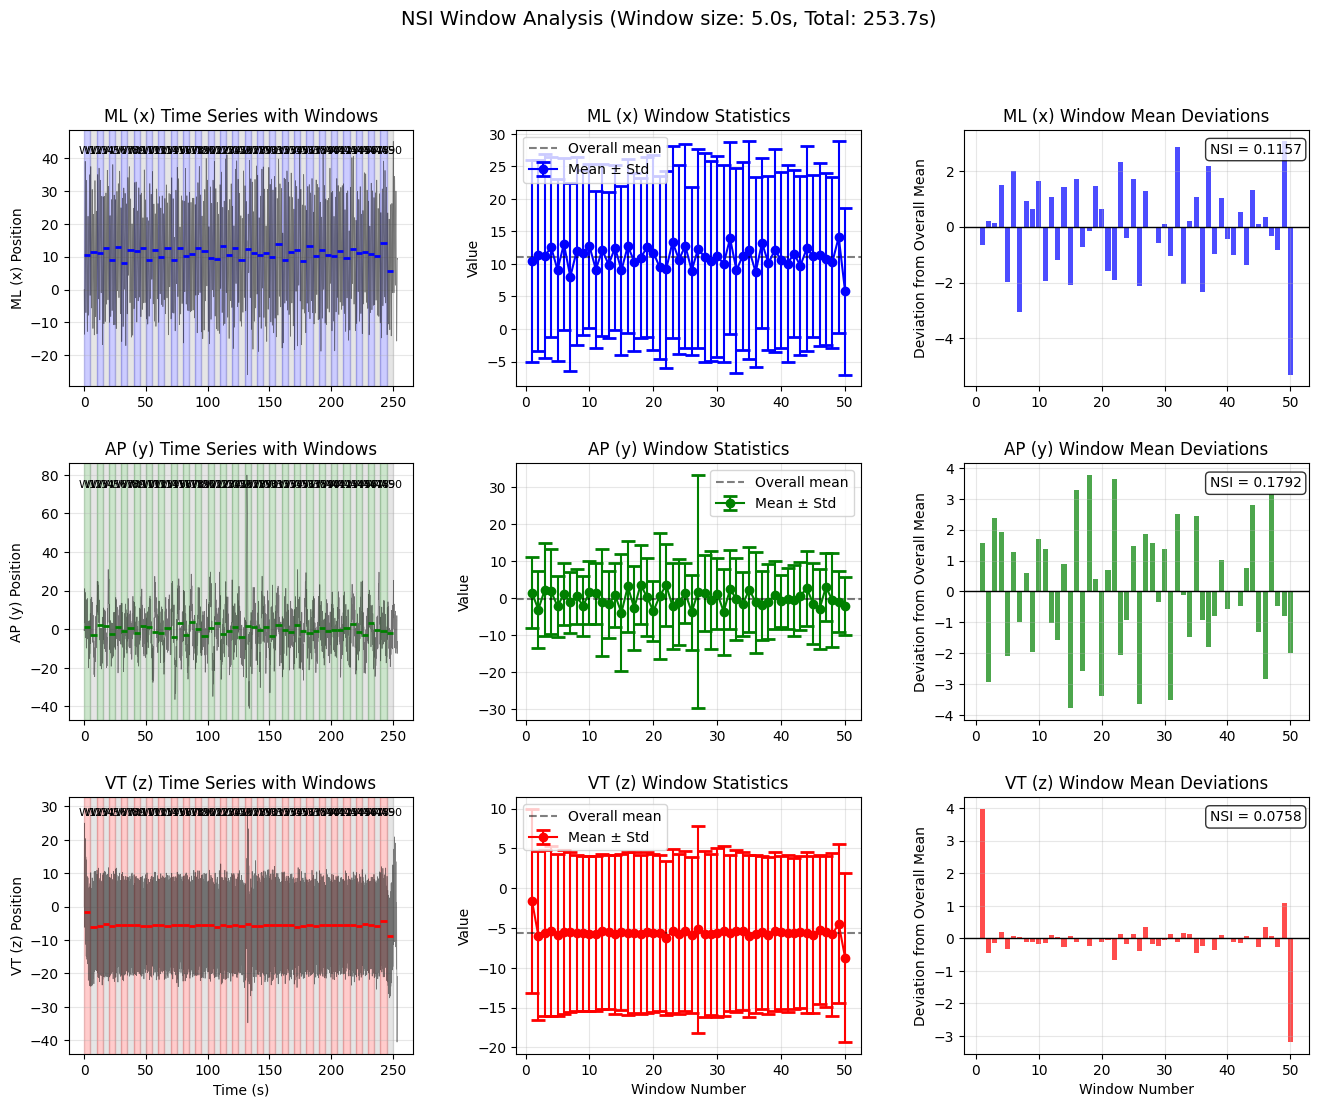

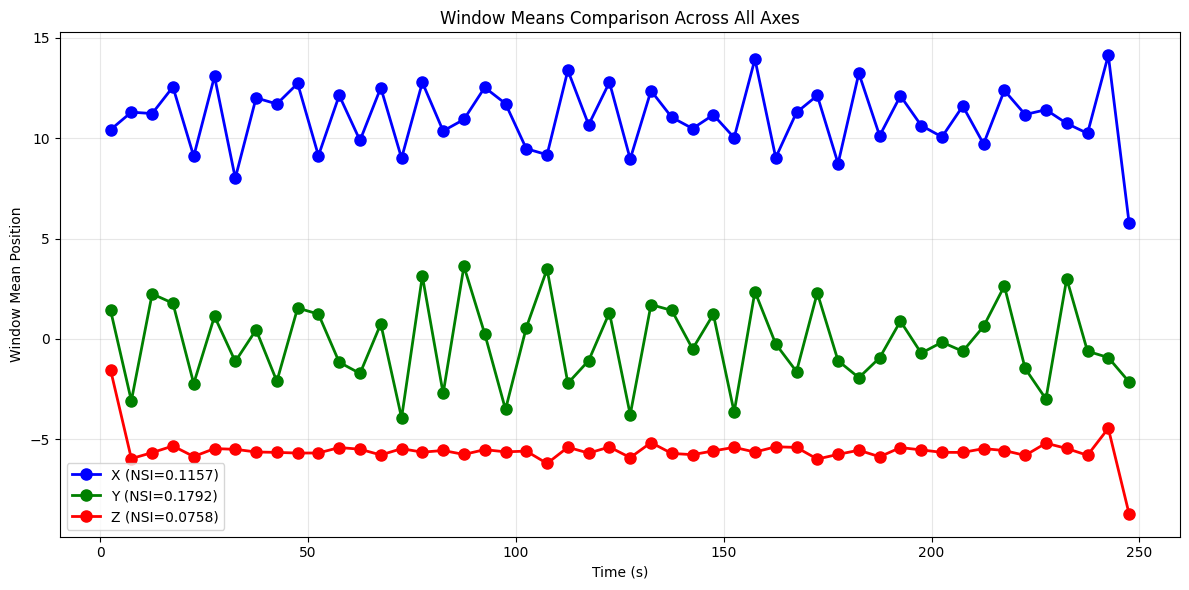

Spatial NSI: ({np.str_('x'): np.float64(0.11571775612253637), np.str_('y'): np.float64(0.1791609041116913), np.str_('z'): np.float64(0.07584840829748088)}, {np.str_('x'): [((0, 500), np.float64(10.42441209545177), np.float64(15.497523204954271)), ((500, 1000), np.float64(11.299666497292762), np.float64(14.688701094775528)), ((1000, 1500), np.float64(11.229037363971177), np.float64(15.718210917309618)), ((1500, 2000), np.float64(12.558424600935762), np.float64(13.823952177168305)), ((2000, 2500), np.float64(9.09851907966032), np.float64(14.032704855587161)), ((2500, 3000), np.float64(13.08172957075451), np.float64(13.200524435458426)), ((3000, 3500), np.float64(8.009863351963036), np.float64(14.432674488047496)), ((3500, 4000), np.float64(12.010643135911364), np.float64(14.448980173193226)), ((4000, 4500), np.float64(11.707478910150519), np.float64(12.685959711066586)), ((4500, 5000), np.float64(12.728176732709322), np.float64(12.572406123166024)), ((5000, 5500), np.float64(9.1281983075

In [49]:
# cwd = Path.cwd()
# print("Current working directory:", cwd.resolve())

data_path = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_16"/"Pre.3" /"markers.nc"
events_path  = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_16"/"Pre.4" /"Cereneo_SR_16_Fam_pre.4_events.csv"

ds_16 = xr.open_dataarray(data_path)
print("Markers DataArray loaded with shape:", ds_16.shape)
df_events_16 = pd.read_csv(events_path)
print("Events DataFrame loaded with shape:", df_events_16.shape)



nsi_temporal_16 = compute_temporal_nsi_from_events(df_events_16, strides_per_window=10, trim_strides=5, outlier_thresh=3.0)
print("Temporal NSI:", nsi_temporal_16)


nsi_spatial_16= compute_spatial_nsi(ds_16, window_samples=500, fs=100.0)
print("Spatial NSI:", nsi_spatial_16)



# Patient 17

Markers DataArray loaded with shape: (3, 95, 24023)
Events DataFrame loaded with shape: (860, 4)
Temporal NSI: 0.6190699017679995


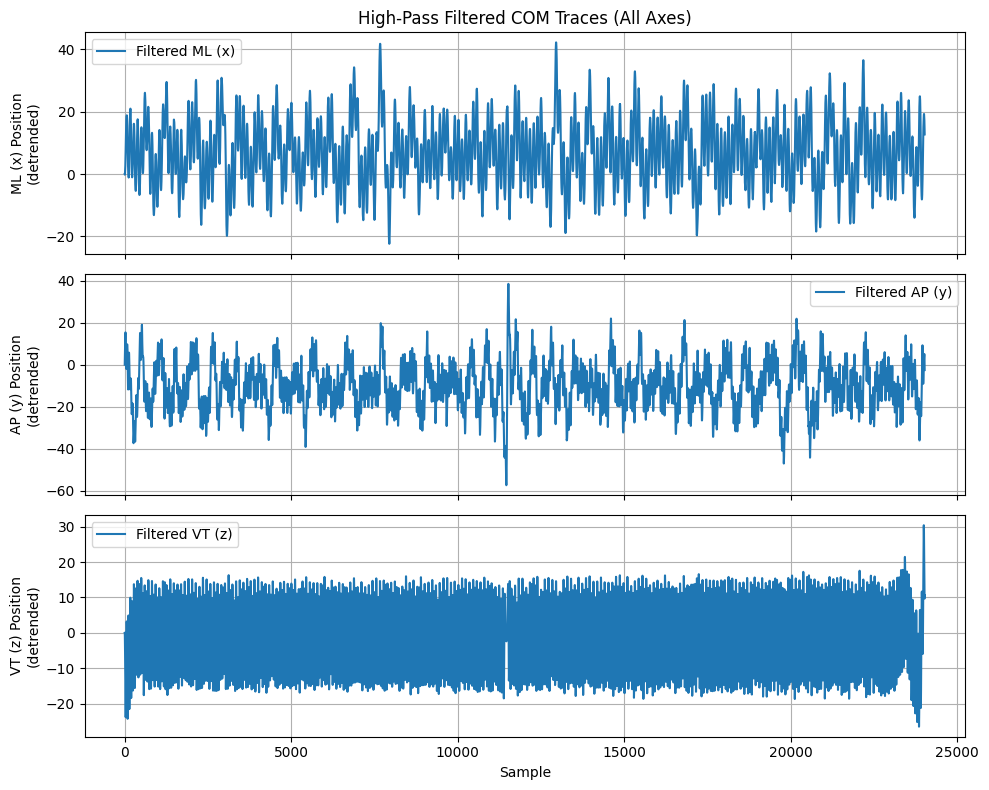

COM series length: 24023 samples (240.23 s)
Window size:       500 samples (5.00 s)
Number of windows: 48
--------------------------------------------------------------------------------

Axis: x
Overall NSI: 0.2220
Window          Time Range (s)       Mean         Std         
------------------------------------------------------------
Window 1          0.00 -   5.00 s      7.2825      8.0322
Window 2          5.00 -  10.00 s      5.9175     10.6547
Window 3         10.00 -  15.00 s     10.1588      9.4830
Window 4         15.00 -  20.00 s      4.2608      8.8199
Window 5         20.00 -  25.00 s      7.5683     11.7595
Window 6         25.00 -  30.00 s     11.2225     11.2116
Window 7         30.00 -  35.00 s      3.8984     12.9061
Window 8         35.00 -  40.00 s      5.9453      9.2771
Window 9         40.00 -  45.00 s      6.1394     10.6053
Window 10        45.00 -  50.00 s      9.2428      9.4975
Window 11        50.00 -  55.00 s      4.9209      9.3224
Window 12        55.00

C:\Users\Natascha\AppData\Local\Temp\ipykernel_74216\1935605621.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


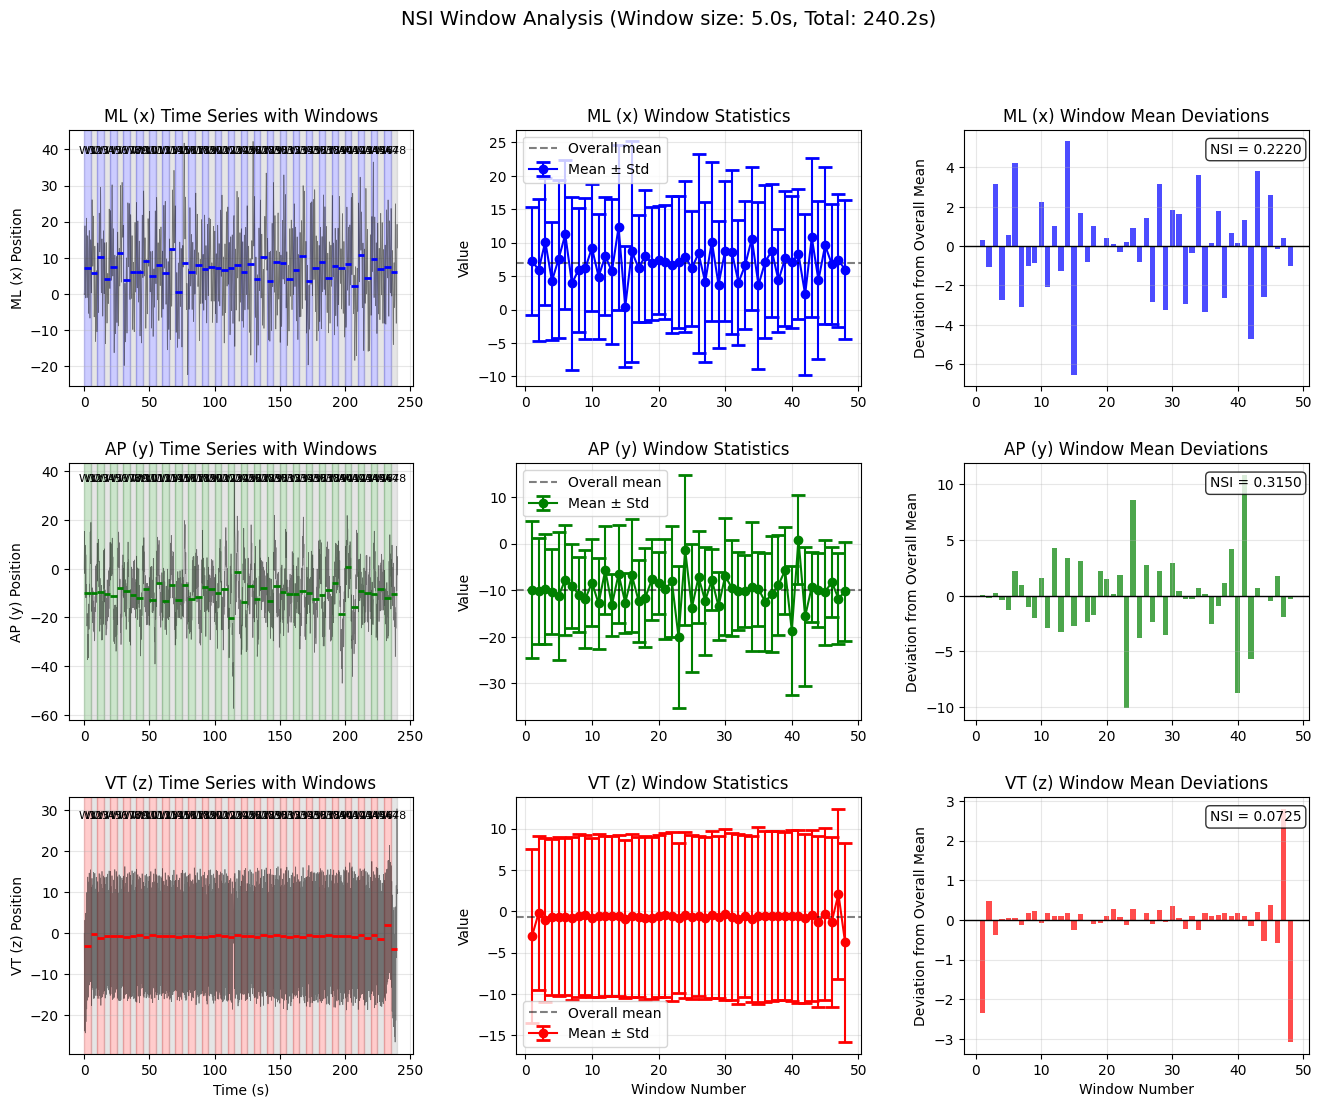

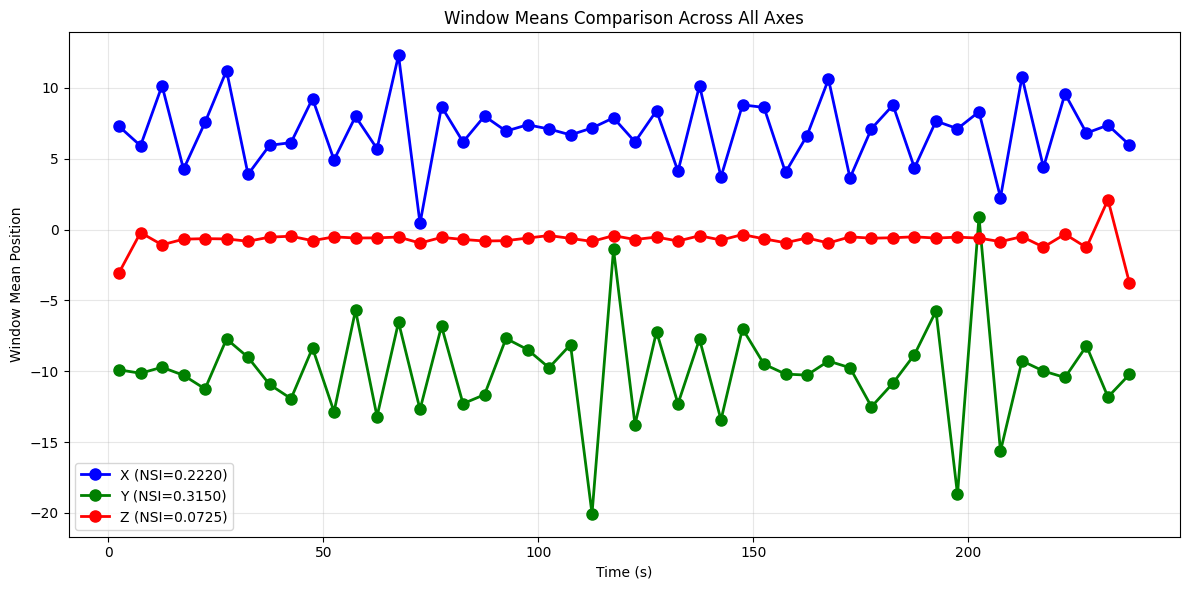

Spatial NSI: ({np.str_('x'): np.float64(0.2220434147275667), np.str_('y'): np.float64(0.3150245782138145), np.str_('z'): np.float64(0.07252477254625178)}, {np.str_('x'): [((0, 500), np.float64(7.282518113399999), np.float64(8.032169034986659)), ((500, 1000), np.float64(5.917543464440444), np.float64(10.654661451126614)), ((1000, 1500), np.float64(10.158841704365615), np.float64(9.4829929355772)), ((1500, 2000), np.float64(4.260806294727572), np.float64(8.819921601765024)), ((2000, 2500), np.float64(7.568306781467536), np.float64(11.759549024297714)), ((2500, 3000), np.float64(11.222479286135062), np.float64(11.211614654889521)), ((3000, 3500), np.float64(3.8983772009334974), np.float64(12.906082060839823)), ((3500, 4000), np.float64(5.9452682549897276), np.float64(9.277106730760286)), ((4000, 4500), np.float64(6.139360871381529), np.float64(10.605294998923545)), ((4500, 5000), np.float64(9.242836500726492), np.float64(9.49751937863221)), ((5000, 5500), np.float64(4.920929813863634), np

In [48]:
# cwd = Path.cwd()
# print("Current working directory:", cwd.resolve())

data_path = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_17"/"Pre.3" /"markers.nc"
events_path  = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_17"/"Pre.4" /"events.csv"

ds_17 = xr.open_dataarray(data_path)
print("Markers DataArray loaded with shape:", ds_17.shape)
df_events_17 = pd.read_csv(events_path)
print("Events DataFrame loaded with shape:", df_events_17.shape)



nsi_temporal_17 = compute_temporal_nsi_from_events(df_events_17, strides_per_window=10, trim_strides=5, outlier_thresh=3.0)
print("Temporal NSI:", nsi_temporal_17)


nsi_spatial_17= compute_spatial_nsi(ds_17, window_samples=500, fs=100.0)
print("Spatial NSI:", nsi_spatial_17)



# Patient 18

Markers DataArray loaded with shape: (3, 95, 24669)
Events DataFrame loaded with shape: (948, 4)
Temporal NSI: 0.38581893421654856


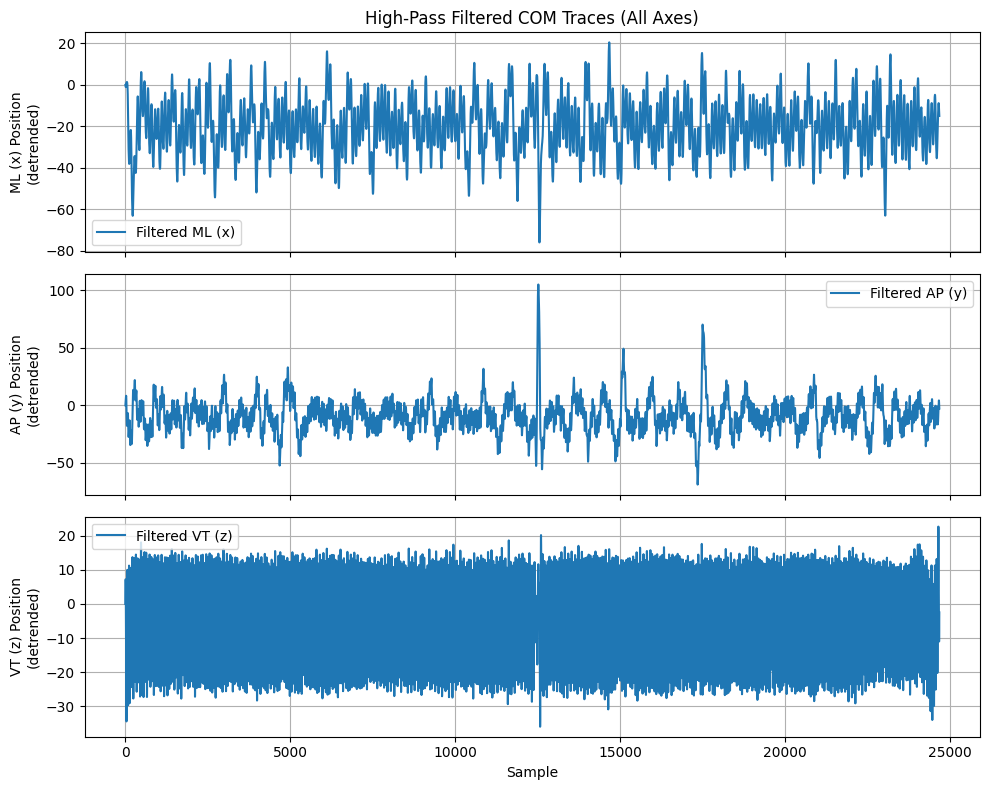

COM series length: 24669 samples (246.69 s)
Window size:       500 samples (5.00 s)
Number of windows: 49
--------------------------------------------------------------------------------

Axis: x
Overall NSI: 0.1659
Window          Time Range (s)       Mean         Std         
------------------------------------------------------------
Window 1          0.00 -   5.00 s    -24.4499     18.9844
Window 2          5.00 -  10.00 s    -17.3150     10.3090
Window 3         10.00 -  15.00 s    -18.0836     11.0684
Window 4         15.00 -  20.00 s    -22.3209     12.9599
Window 5         20.00 -  25.00 s    -19.4352     13.5737
Window 6         25.00 -  30.00 s    -20.9737     15.5737
Window 7         30.00 -  35.00 s    -19.4052     15.2305
Window 8         35.00 -  40.00 s    -19.1143     13.7910
Window 9         40.00 -  45.00 s    -20.7163     13.1787
Window 10        45.00 -  50.00 s    -17.6135     10.1356
Window 11        50.00 -  55.00 s    -18.8457     10.9877
Window 12        55.00

C:\Users\Natascha\AppData\Local\Temp\ipykernel_74216\1935605621.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


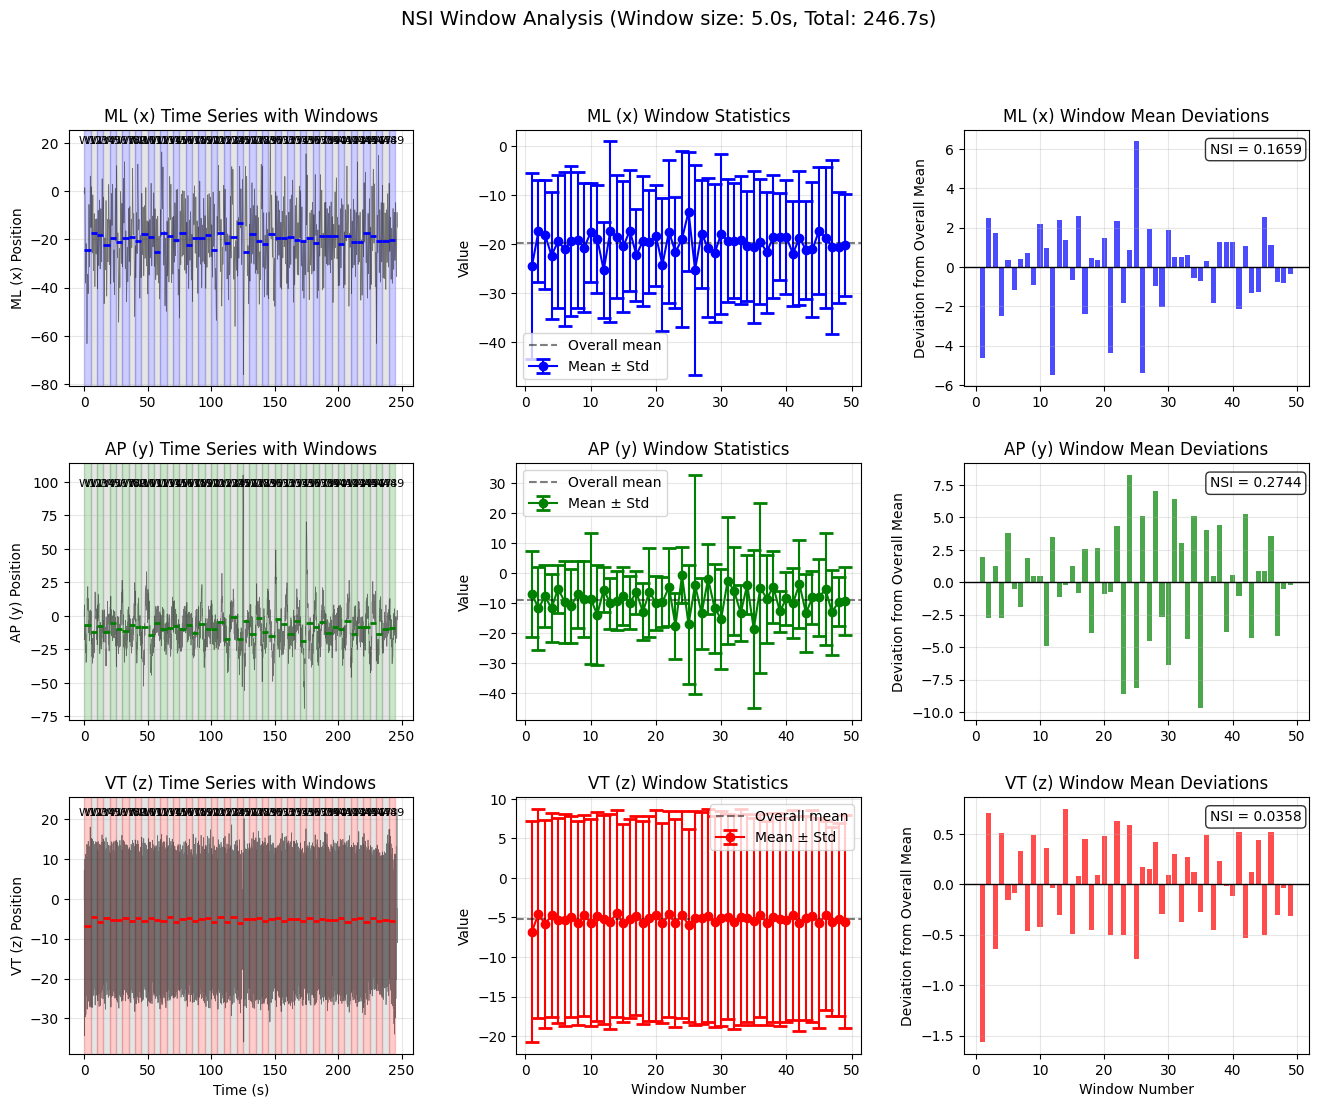

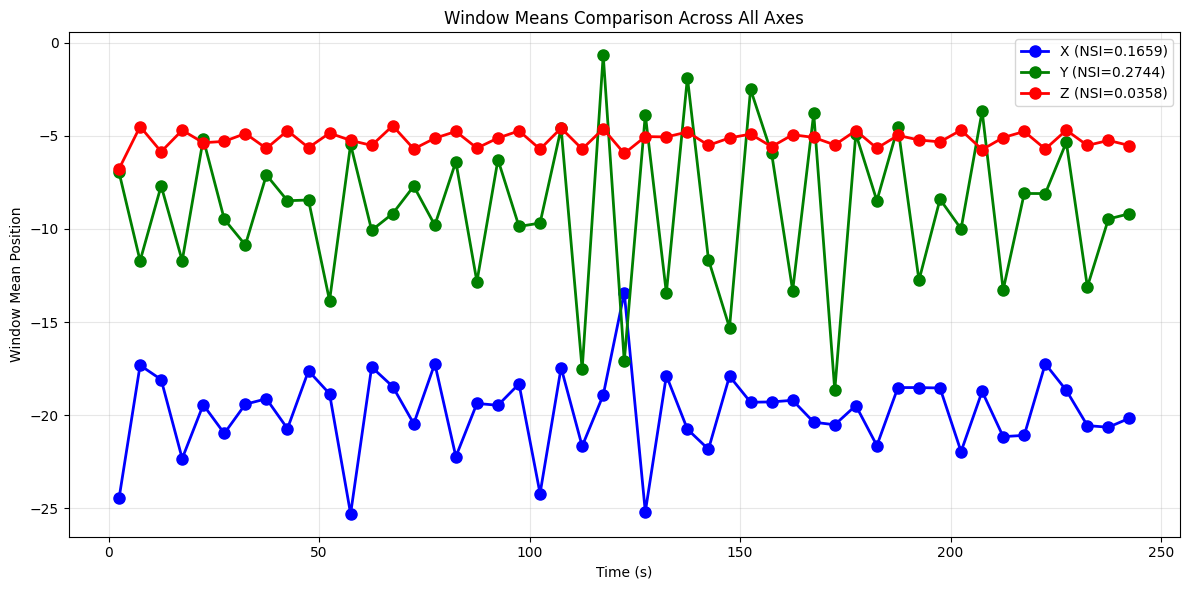

Spatial NSI: ({np.str_('x'): np.float64(0.16590544111210428), np.str_('y'): np.float64(0.27436394375158407), np.str_('z'): np.float64(0.03581251622483111)}, {np.str_('x'): [((0, 500), np.float64(-24.449902383207174), np.float64(18.98440367123196)), ((500, 1000), np.float64(-17.314980127913927), np.float64(10.308966113248834)), ((1000, 1500), np.float64(-18.083566697308715), np.float64(11.068362159892292)), ((1500, 2000), np.float64(-22.320913238605442), np.float64(12.959880038766299)), ((2000, 2500), np.float64(-19.435195349263168), np.float64(13.573684440732752)), ((2500, 3000), np.float64(-20.97365458891631), np.float64(15.5737137242367)), ((3000, 3500), np.float64(-19.40520441140252), np.float64(15.230511973316297)), ((3500, 4000), np.float64(-19.114279640870066), np.float64(13.790984180652107)), ((4000, 4500), np.float64(-20.716282912719784), np.float64(13.178669502533705)), ((4500, 5000), np.float64(-17.613503239547793), np.float64(10.135584124336592)), ((5000, 5500), np.float64(-

In [47]:
# cwd = Path.cwd()
# print("Current working directory:", cwd.resolve())

data_path = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_18"/"Pre.3" /"markers.nc"
events_path  = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_18"/"Pre.4" /"events.csv"

ds_18 = xr.open_dataarray(data_path)
print("Markers DataArray loaded with shape:", ds_18.shape)
df_events_18 = pd.read_csv(events_path)
print("Events DataFrame loaded with shape:", df_events_18.shape)



nsi_temporal_18 = compute_temporal_nsi_from_events(df_events_18, strides_per_window=10, trim_strides=5, outlier_thresh=3.0)
print("Temporal NSI:", nsi_temporal_18)


nsi_spatial_18= compute_spatial_nsi(ds_18, window_samples=500, fs=100.0)
print("Spatial NSI:", nsi_spatial_18)

